# 🌊 Détection des Inondations — Étude Comparative de Modèles
## Pour publication académique

**Modèles comparés :**

| Modèle | Architecture | Paramètres | Nouveauté |
|--------|-------------|-----------|-----------|
| ResNet18 | CNN résiduel classique | 11M | Baseline (2015) |
| EfficientNet-B3 | CNN compound scaling | 12M | Efficacité (2019) |
| ConvNeXt-Tiny | CNN modernisé | 28M | SOTA convolutif (2022) |
| Swin-Tiny | Transformer hiérarchique | 28M | Attention globale (2021) |

**Techniques d'entraînement communes :**
- Fine-tuning progressif (3 phases)
- Mixup + CutMix augmentation
- Early Stopping + LR Warmup
- Gradient Clipping

---

In [ ]:
# !pip install torch torchvision timm scikit-learn matplotlib seaborn pillow tqdm opencv-python

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import timm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, f1_score, precision_score,
                              recall_score, accuracy_score)
from collections import Counter
import warnings, cv2, time, json
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")
print(f"PyTorch : {torch.__version__}")
print(f"timm    : {timm.__version__}")


Device  : cuda
PyTorch : 2.9.0+cu128
timm    : 1.0.24


## 1. Configuration globale

In [ ]:
# ─── Chemins ──────────────────────────────────────────────────────────
DATA_DIR = "/content/drive/MyDrive/memoire/donnee/inondation_senegal/flood_dataset"

# ─── Hyperparamètres communs à tous les modèles ───────────────────────
CONFIG = {
    'batch_size'     : 16,
    'num_workers'    : 2,
    'img_size'       : 224,
    'phase1_epochs'  : 5,    # backbone gelé  + warmup
    'phase2_epochs'  : 8,    # couches profondes dégelées
    'phase3_epochs'  : 12,   # fine-tuning complet
    'phase1_lr'      : 1e-3,
    'phase2_lr'      : 1e-4,
    'phase3_lr'      : 3e-5,
    'weight_decay'   : 0.02,
    'patience'       : 7,    # early stopping
    'mixup_alpha'    : 0.4,
    'cutmix_alpha'   : 1.0,
}

# ─── Modèles à comparer ──────────────────────────────────────────────
MODELS_CONFIG = {
    'ResNet18'       : {'timm_name': 'resnet18',        'last_layer': 'layer4'},
    'EfficientNet-B3': {'timm_name': 'efficientnet_b3', 'last_layer': 'blocks'},
    'ConvNeXt-Tiny'  : {'timm_name': 'convnext_tiny',   'last_layer': 'stages'},
    'Swin-Tiny'      : {'timm_name': 'swin_tiny_patch4_window7_224', 'last_layer': 'layers'},
}

# Dictionnaire pour stocker les résultats de tous les modèles
ALL_RESULTS = {}

print("Configuration chargée :")
for k, v in CONFIG.items():
    print(f"  {k:20s} : {v}")
print(f"\nModèles à entraîner : {list(MODELS_CONFIG.keys())}")


Configuration chargée :
  batch_size           : 16
  num_workers          : 2
  img_size             : 224
  phase1_epochs        : 5
  phase2_epochs        : 8
  phase3_epochs        : 12
  phase1_lr            : 0.001
  phase2_lr            : 0.0001
  phase3_lr            : 3e-05
  weight_decay         : 0.02
  patience             : 7
  mixup_alpha          : 0.4
  cutmix_alpha         : 1.0

Modèles à entraîner : ['ResNet18', 'EfficientNet-B3', 'ConvNeXt-Tiny', 'Swin-Tiny']


## 2. Dataset & Transforms

In [ ]:
# ─── Transforms ──────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.85,1.15), shear=10),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1,1.5)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02,0.1))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_dataset = ImageFolder(root=f"{DATA_DIR}/train", transform=train_transform)
val_dataset   = ImageFolder(root=f"{DATA_DIR}/val",   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True,  num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)

labels_list = [label for _, label in train_dataset]
counts = Counter(labels_list)
total  = sum(counts.values())
class_weights = torch.FloatTensor([total/counts[i] for i in sorted(counts.keys())]).to(device)

print(f"Train   : {len(train_dataset)} images")
print(f"Val     : {len(val_dataset)} images")
print(f"Classes : {train_dataset.classes}")
print(f"Poids   : {class_weights}")


Train   : 820 images
Val     : 113 images
Classes : ['inondation', 'non_inondation']
Poids   : tensor([2., 2.], device='cuda:0')


## 3. Mixup & CutMix

In [ ]:
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    B, _, H, W = x.size()
    idx = torch.randperm(B).to(x.device)
    cr = np.sqrt(1.0 - lam)
    ch, cw = int(H*cr), int(W*cr)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1,x2 = np.clip(cx-cw//2,0,W), np.clip(cx+cw//2,0,W)
    y1,y2 = np.clip(cy-ch//2,0,H), np.clip(cy+ch//2,0,H)
    mixed = x.clone()
    mixed[:,:,y1:y2,x1:x2] = x[idx,:,y1:y2,x1:x2]
    lam = 1 - (x2-x1)*(y2-y1)/(W*H)
    return mixed, y, y[idx], lam

def aug_criterion(criterion, pred, ya, yb, lam):
    return lam*criterion(pred,ya) + (1-lam)*criterion(pred,yb)

print("✅ Mixup et CutMix prêts")


✅ Mixup et CutMix prêts


## 4. Architecture commune — FloodClassifier

Tous les modèles partagent la **même interface** :
- Chargement via `timm` avec poids ImageNet
- 3 méthodes de gel/dégel progressif
- Forward identique → comparaison équitable

In [ ]:
class FloodClassifier(nn.Module):
    def __init__(self, model_name, num_classes=2, pretrained=True):
        super().__init__()
        self.model_name = model_name
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def _count_trainable(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def freeze_backbone(self):
        """Phase 1 : seule la tête s'entraîne."""
        head_keywords = ['fc','head','classifier','last_linear']
        for name, param in self.model.named_parameters():
            param.requires_grad = any(k in name for k in head_keywords)
        print(f"  [Phase 1] {self._count_trainable():>10,} params entraînables (tête seule)")

    def unfreeze_deep(self):
        """Phase 2 : dégèle les couches profondes."""
        deep_keywords = ['layer4','blocks.5','blocks.6','blocks.7',
                         'stages.3','layers.3','head','fc','classifier']
        for name, param in self.model.named_parameters():
            if any(k in name for k in deep_keywords):
                param.requires_grad = True
        print(f"  [Phase 2] {self._count_trainable():>10,} params entraînables (+ couches profondes)")

    def unfreeze_all(self):
        """Phase 3 : tout le réseau."""
        for param in self.parameters():
            param.requires_grad = True
        print(f"  [Phase 3] {self._count_trainable():>10,} params entraînables (réseau complet)")


class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001, path='best_model.pth'):
        self.patience=patience; self.min_delta=min_delta; self.path=path
        self.best=None; self.counter=0; self.stop=False

    def __call__(self, val_acc, model):
        if self.best is None or val_acc > self.best + self.min_delta:
            self.best = val_acc
            torch.save(model.state_dict(), self.path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def reset(self):
        self.counter=0; self.stop=False

print("✅ FloodClassifier et EarlyStopping définis")


✅ FloodClassifier et EarlyStopping définis


## 5. Fonctions d'entraînement & évaluation

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device, use_aug=True, alpha=0.4):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        do_aug = use_aug and np.random.rand() > 0.5
        if do_aug:
            fn = mixup_data if np.random.rand() > 0.5 else cutmix_data
            x, ya, yb, lam = fn(x, y, alpha)
        optimizer.zero_grad()
        out  = model(x)
        loss = aug_criterion(criterion, out, ya, yb, lam) if do_aug else criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        _, pred = torch.max(out, 1)
        total   += y.size(0)
        correct += (pred == y).sum().item()
    return total_loss/len(loader), 100*correct/total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    preds_all, labels_all, probs_all = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            probs = torch.softmax(out, 1)
            _, pred = torch.max(out, 1)
            total_loss += loss.item()
            total   += y.size(0)
            correct += (pred == y).sum().item()
            preds_all.extend(pred.cpu().numpy())
            labels_all.extend(y.cpu().numpy())
            probs_all.extend(probs[:,1].cpu().numpy())
    acc = 100*correct/total
    return total_loss/len(loader), acc, preds_all, labels_all, probs_all


def compute_metrics(labels, preds, probs, model_name, train_time):
    """Calcule toutes les métriques pour le tableau comparatif."""
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    return {
        'model'    : model_name,
        'accuracy' : round(accuracy_score(labels, preds)*100, 2),
        'precision': round(precision_score(labels, preds, average='weighted')*100, 2),
        'recall'   : round(recall_score(labels, preds, average='weighted')*100, 2),
        'f1'       : round(f1_score(labels, preds, average='weighted')*100, 2),
        'auc_roc'  : round(roc_auc, 4),
        'recall_flood': round(recall_score(labels, preds, pos_label=0)*100, 2),
        'train_time_min': round(train_time/60, 1),
        'fpr': fpr, 'tpr': tpr,
        'preds': preds, 'labels': labels, 'probs': probs,
    }

print("✅ Fonctions d'entraînement et d'évaluation définies")


✅ Fonctions d'entraînement et d'évaluation définies


## 6. Boucle d'entraînement comparative

Chaque modèle suit exactement le **même protocole en 3 phases** pour une comparaison équitable.
Le meilleur checkpoint de chaque modèle est sauvegardé séparément.

> ⏱️ Temps estimé sur Colab T4 : ~15–20 min par modèle

In [ ]:
def train_model(model_name, timm_name, cfg, train_loader, val_loader,
                criterion, device, verbose=True):
    """Entraîne un modèle selon le protocole 3 phases et retourne ses métriques."""
    print(f"\n{'='*70}")
    print(f"  ENTRAÎNEMENT : {model_name}  ({timm_name})")
    print(f"{'='*70}")

    model = FloodClassifier(timm_name, num_classes=2, pretrained=True).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Paramètres totaux : {total_params:,}")

    save_path = f"best_{model_name.replace('-','_').replace('/','_')}.pth"
    es = EarlyStopping(patience=cfg['patience'], path=save_path)
    history = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[],'lr':[]}

    t_start = time.time()

    # ── Phase 1 : backbone gelé + warmup ────────────────────────────
    print(f"\n  ── Phase 1 : backbone gelé (LR warmup, {cfg['phase1_epochs']} epochs)")
    model.freeze_backbone()
    opt = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=cfg['phase1_lr'], weight_decay=cfg['weight_decay'])
    warmup = optim.lr_scheduler.LambdaLR(
        opt, lambda e: 1e-6/cfg['phase1_lr'] + (1-1e-6/cfg['phase1_lr'])*e/cfg['phase1_epochs'])

    for ep in range(cfg['phase1_epochs']):
        tl, ta = train_epoch(model, train_loader, criterion, opt, device, use_aug=True)
        vl, va, vp, vl2, vprob = evaluate(model, val_loader, criterion, device)
        warmup.step()
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)
        history['lr'].append(opt.param_groups[0]['lr'])
        if verbose: print(f"    [P1 {ep+1}/{cfg['phase1_epochs']}] Train {ta:.1f}% | Val {va:.1f}% | LR {opt.param_groups[0]['lr']:.1e}")
        es(va, model)
        if es.stop: print("    Early stop P1"); break

    # ── Phase 2 : couches profondes ──────────────────────────────────
    if not es.stop:
        print(f"\n  ── Phase 2 : couches profondes ({cfg['phase2_epochs']} epochs)")
        model.unfreeze_deep(); es.reset()
        opt = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                          lr=cfg['phase2_lr'], weight_decay=cfg['weight_decay'])
        sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['phase2_epochs'], eta_min=1e-6)

        for ep in range(cfg['phase2_epochs']):
            tl, ta = train_epoch(model, train_loader, criterion, opt, device, use_aug=True)
            vl, va, vp, vl2, vprob = evaluate(model, val_loader, criterion, device)
            sch.step()
            history['train_loss'].append(tl); history['train_acc'].append(ta)
            history['val_loss'].append(vl);   history['val_acc'].append(va)
            history['lr'].append(opt.param_groups[0]['lr'])
            if verbose: print(f"    [P2 {ep+1}/{cfg['phase2_epochs']}] Train {ta:.1f}% | Val {va:.1f}% | LR {opt.param_groups[0]['lr']:.1e}")
            es(va, model)
            if es.stop: print("    Early stop P2"); break

    # ── Phase 3 : fine-tuning complet ────────────────────────────────
    if not es.stop:
        print(f"\n  ── Phase 3 : fine-tuning global ({cfg['phase3_epochs']} epochs)")
        model.unfreeze_all(); es.reset()
        opt = optim.AdamW(model.parameters(), lr=cfg['phase3_lr'], weight_decay=cfg['weight_decay']/2)
        sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['phase3_epochs'], eta_min=1e-7)

        for ep in range(cfg['phase3_epochs']):
            tl, ta = train_epoch(model, train_loader, criterion, opt, device, use_aug=True, alpha=0.3)
            vl, va, vp, vl2, vprob = evaluate(model, val_loader, criterion, device)
            sch.step()
            history['train_loss'].append(tl); history['train_acc'].append(ta)
            history['val_loss'].append(vl);   history['val_acc'].append(va)
            history['lr'].append(opt.param_groups[0]['lr'])
            if verbose: print(f"    [P3 {ep+1}/{cfg['phase3_epochs']}] Train {ta:.1f}% | Val {va:.1f}% | LR {opt.param_groups[0]['lr']:.1e}")
            es(va, model)
            if es.stop: print("    Early stop P3"); break

    train_time = time.time() - t_start

    # ── Évaluation finale sur le meilleur checkpoint ─────────────────
    model.load_state_dict(torch.load(save_path))
    _, final_acc, final_preds, final_labels, final_probs = evaluate(model, val_loader, criterion, device)
    metrics = compute_metrics(final_labels, final_preds, final_probs, model_name, train_time)
    metrics['history'] = history
    metrics['model_obj'] = model
    metrics['total_params'] = total_params

    print(f"\n  ✅ {model_name} terminé en {train_time/60:.1f} min")
    print(f"     Accuracy={metrics['accuracy']}% | Recall(flood)={metrics['recall_flood']}% | AUC={metrics['auc_roc']}")
    return metrics


# ─── Entraîner tous les modèles ──────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights)

for model_name, mcfg in MODELS_CONFIG.items():
    ALL_RESULTS[model_name] = train_model(
        model_name, mcfg['timm_name'], CONFIG,
        train_loader, val_loader, criterion, device
    )

print("\n" + "="*70)
print("TOUS LES MODÈLES ENTRAÎNÉS")
print("="*70)



  ENTRAÎNEMENT : ResNet18  (resnet18)


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

  Paramètres totaux : 11,177,538

  ── Phase 1 : backbone gelé (LR warmup, 5 epochs)
  [Phase 1]      1,026 params entraînables (tête seule)
    [P1 1/5] Train 48.8% | Val 54.0% | LR 2.0e-04
    [P1 2/5] Train 50.4% | Val 59.3% | LR 4.0e-04
    [P1 3/5] Train 55.5% | Val 71.7% | LR 6.0e-04
    [P1 4/5] Train 61.8% | Val 76.1% | LR 8.0e-04
    [P1 5/5] Train 63.7% | Val 84.1% | LR 1.0e-03

  ── Phase 2 : couches profondes (8 epochs)
  [Phase 2]  8,394,754 params entraînables (+ couches profondes)
    [P2 1/8] Train 69.5% | Val 78.8% | LR 9.6e-05
    [P2 2/8] Train 69.1% | Val 79.6% | LR 8.6e-05
    [P2 3/8] Train 70.4% | Val 75.2% | LR 6.9e-05
    [P2 4/8] Train 73.5% | Val 80.5% | LR 5.1e-05
    [P2 5/8] Train 73.0% | Val 82.3% | LR 3.2e-05
    [P2 6/8] Train 67.7% | Val 79.6% | LR 1.5e-05
    [P2 7/8] Train 72.0% | Val 80.5% | LR 4.8e-06
    Early stop P2

  ✅ ResNet18 terminé en 2.8 min
     Accuracy=84.07% | Recall(flood)=88.06% | AUC=0.8933

  ENTRAÎNEMENT : EfficientNet-B3  (effic

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

  Paramètres totaux : 10,699,306

  ── Phase 1 : backbone gelé (LR warmup, 5 epochs)
  [Phase 1]    592,898 params entraînables (tête seule)
    [P1 1/5] Train 48.7% | Val 48.7% | LR 2.0e-04
    [P1 2/5] Train 57.2% | Val 78.8% | LR 4.0e-04
    [P1 3/5] Train 68.4% | Val 80.5% | LR 6.0e-04
    [P1 4/5] Train 72.2% | Val 71.7% | LR 8.0e-04
    [P1 5/5] Train 69.8% | Val 77.0% | LR 1.0e-03

  ── Phase 2 : couches profondes (8 epochs)
  [Phase 2]  8,506,080 params entraînables (+ couches profondes)
    [P2 1/8] Train 73.0% | Val 79.6% | LR 9.6e-05
    [P2 2/8] Train 76.7% | Val 71.7% | LR 8.6e-05
    [P2 3/8] Train 76.5% | Val 83.2% | LR 6.9e-05
    [P2 4/8] Train 77.0% | Val 89.4% | LR 5.1e-05
    [P2 5/8] Train 79.9% | Val 89.4% | LR 3.2e-05
    [P2 6/8] Train 80.1% | Val 87.6% | LR 1.5e-05
    [P2 7/8] Train 80.0% | Val 85.8% | LR 4.8e-06
    [P2 8/8] Train 83.9% | Val 89.4% | LR 1.0e-06

  ── Phase 3 : fine-tuning global (12 epochs)
  [Phase 3] 10,699,306 params entraînables (réseau c

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Paramètres totaux : 27,821,666

  ── Phase 1 : backbone gelé (LR warmup, 5 epochs)
  [Phase 1] 25,914,722 params entraînables (tête seule)
    [P1 1/5] Train 50.9% | Val 60.2% | LR 2.0e-04
    [P1 2/5] Train 67.7% | Val 91.2% | LR 4.0e-04
    [P1 3/5] Train 70.2% | Val 92.9% | LR 6.0e-04
    [P1 4/5] Train 67.1% | Val 85.8% | LR 8.0e-04
    [P1 5/5] Train 59.5% | Val 47.8% | LR 1.0e-03

  ── Phase 2 : couches profondes (8 epochs)
  [Phase 2] 27,279,074 params entraînables (+ couches profondes)
    [P2 1/8] Train 75.4% | Val 92.9% | LR 9.6e-05
    [P2 2/8] Train 80.6% | Val 91.2% | LR 8.6e-05
    [P2 3/8] Train 80.7% | Val 92.9% | LR 6.9e-05
    [P2 4/8] Train 79.0% | Val 92.9% | LR 5.1e-05
    [P2 5/8] Train 85.2% | Val 95.6% | LR 3.2e-05
    [P2 6/8] Train 83.0% | Val 93.8% | LR 1.5e-05
    [P2 7/8] Train 84.9% | Val 96.5% | LR 4.8e-06
    [P2 8/8] Train 87.9% | Val 96.5% | LR 1.0e-06

  ── Phase 3 : fine-tuning global (12 epochs)
  [Phase 3] 27,821,666 params entraînables (réseau c

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Paramètres totaux : 27,520,892

  ── Phase 1 : backbone gelé (LR warmup, 5 epochs)
  [Phase 1] 17,275,970 params entraînables (tête seule)
    [P1 1/5] Train 50.0% | Val 54.0% | LR 2.0e-04
    [P1 2/5] Train 66.3% | Val 92.0% | LR 4.0e-04
    [P1 3/5] Train 80.7% | Val 96.5% | LR 6.0e-04
    [P1 4/5] Train 75.7% | Val 87.6% | LR 8.0e-04
    [P1 5/5] Train 64.9% | Val 84.1% | LR 1.0e-03

  ── Phase 2 : couches profondes (8 epochs)
  [Phase 2] 23,792,606 params entraînables (+ couches profondes)
    [P2 1/8] Train 78.2% | Val 91.2% | LR 9.6e-05
    [P2 2/8] Train 83.7% | Val 94.7% | LR 8.6e-05
    [P2 3/8] Train 86.2% | Val 94.7% | LR 6.9e-05
    [P2 4/8] Train 85.7% | Val 96.5% | LR 5.1e-05
    [P2 5/8] Train 87.7% | Val 96.5% | LR 3.2e-05
    [P2 6/8] Train 85.7% | Val 96.5% | LR 1.5e-05
    [P2 7/8] Train 89.6% | Val 96.5% | LR 4.8e-06
    Early stop P2

  ✅ Swin-Tiny terminé en 2.8 min
     Accuracy=96.46% | Recall(flood)=97.01% | AUC=0.9932

TOUS LES MODÈLES ENTRAÎNÉS


## 7. Tableau comparatif — Publication Ready

TABLEAU COMPARATIF DES MODÈLES
                Params (M)  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  AUC-ROC  Recall Inond. (%)  Temps (min)
Modèle                                                                                                                    
ResNet18              11.2         84.07          84.01       84.07         84.01   0.8933              88.06          2.8
EfficientNet-B3       10.7         92.04          92.24       92.04         92.07   0.9757              91.04          5.1
ConvNeXt-Tiny         27.8         97.35          97.51       97.35         97.36   0.9893              95.52          6.1
Swin-Tiny             27.5         96.46          96.46       96.46         96.46   0.9932              97.01          2.8


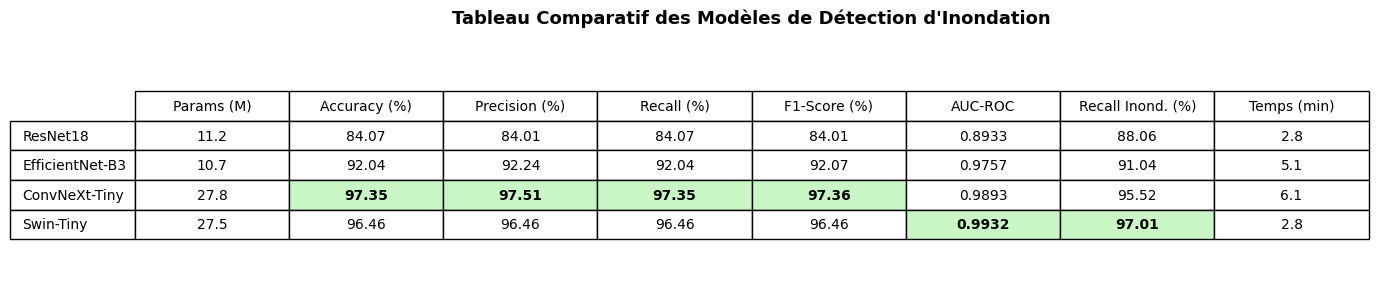


Cellules en vert = meilleure valeur par métrique
Exporté : comparison_results.csv


In [ ]:
import pandas as pd

# ─── Construire le tableau ────────────────────────────────────────────
rows = []
for name, r in ALL_RESULTS.items():
    rows.append({
        'Modèle'           : name,
        'Params (M)'       : f"{r['total_params']/1e6:.1f}",
        'Accuracy (%)'     : r['accuracy'],
        'Precision (%)'    : r['precision'],
        'Recall (%)'       : r['recall'],
        'F1-Score (%)'     : r['f1'],
        'AUC-ROC'          : r['auc_roc'],
        'Recall Inond. (%)': r['recall_flood'],
        'Temps (min)'      : r['train_time_min'],
    })

df = pd.DataFrame(rows).set_index('Modèle')
print("="*90)
print("TABLEAU COMPARATIF DES MODÈLES")
print("="*90)
print(df.to_string())
print("="*90)

# ─── Figure publication-ready ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')
table = ax.table(
    cellText  = df.values,
    colLabels = df.columns,
    rowLabels = df.index,
    cellLoc   = 'center',
    loc       = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Colorier la meilleure valeur en vert pour les colonnes numériques
metric_cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)',
               'AUC-ROC', 'Recall Inond. (%)']
col_indices = {c: list(df.columns).index(c) for c in metric_cols}
for col_name, col_idx in col_indices.items():
    vals = pd.to_numeric(df[col_name])
    best_row = vals.idxmax()
    best_row_idx = list(df.index).index(best_row)
    table[(best_row_idx+1, col_idx)].set_facecolor('#c8f7c5')
    table[(best_row_idx+1, col_idx)].set_text_props(fontweight='bold')

plt.title('Tableau Comparatif des Modèles de Détection d\'Inondation',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('comparison_table.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nCellules en vert = meilleure valeur par métrique")

# Export CSV pour le mémoire
df.to_csv('comparison_results.csv')
print("Exporté : comparison_results.csv")


## 8. Visualisations comparatives

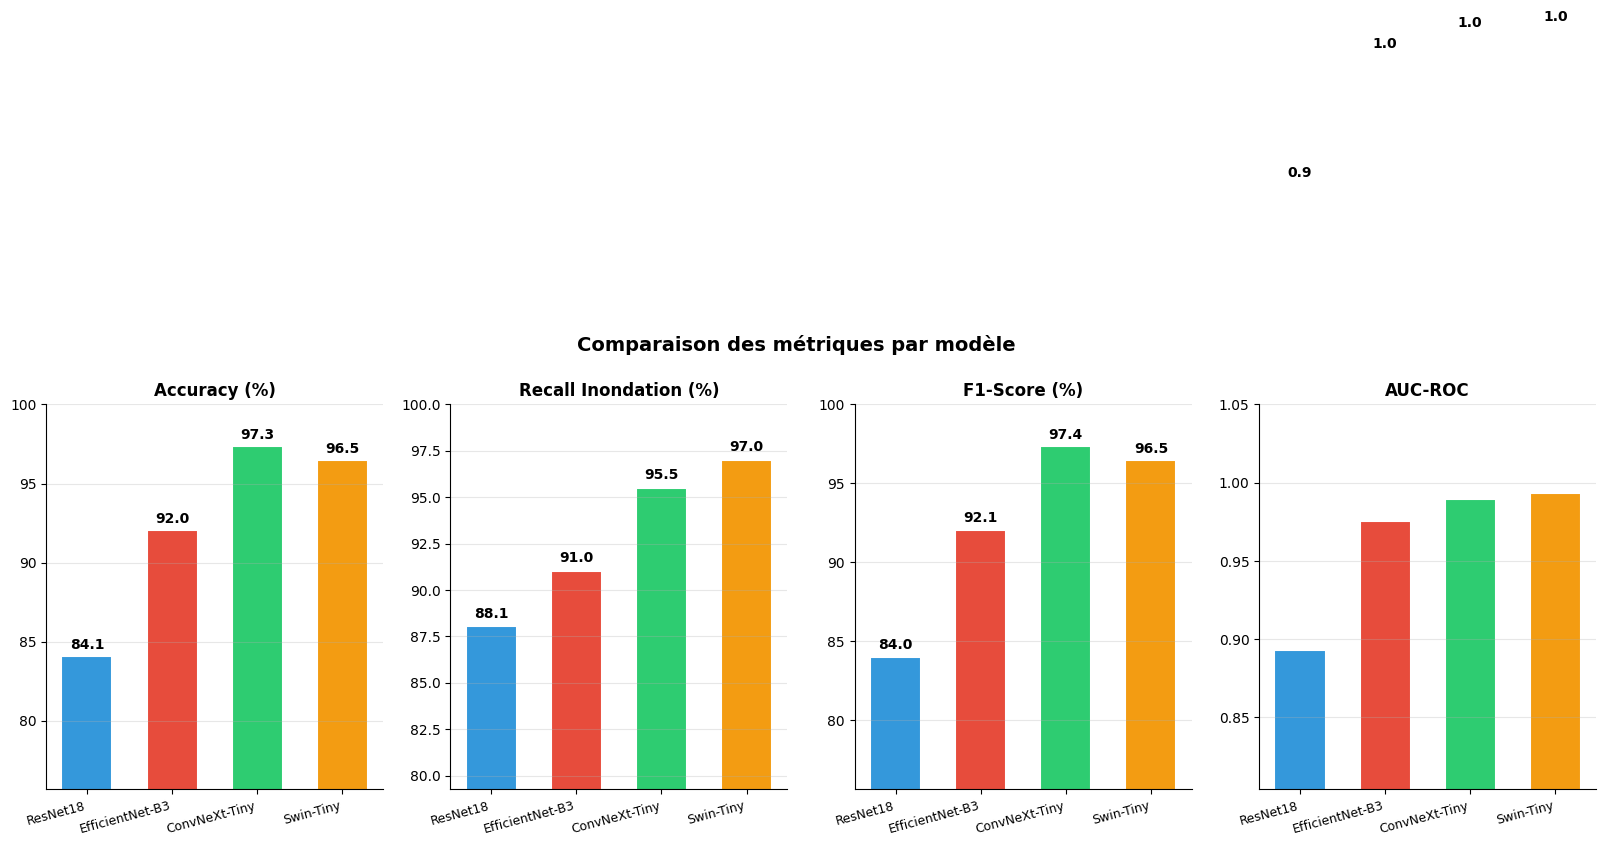

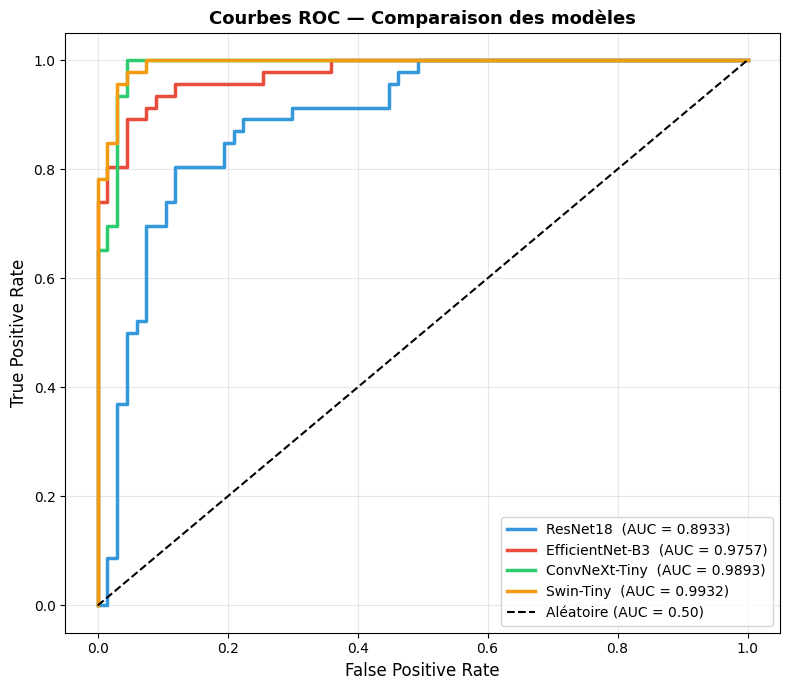

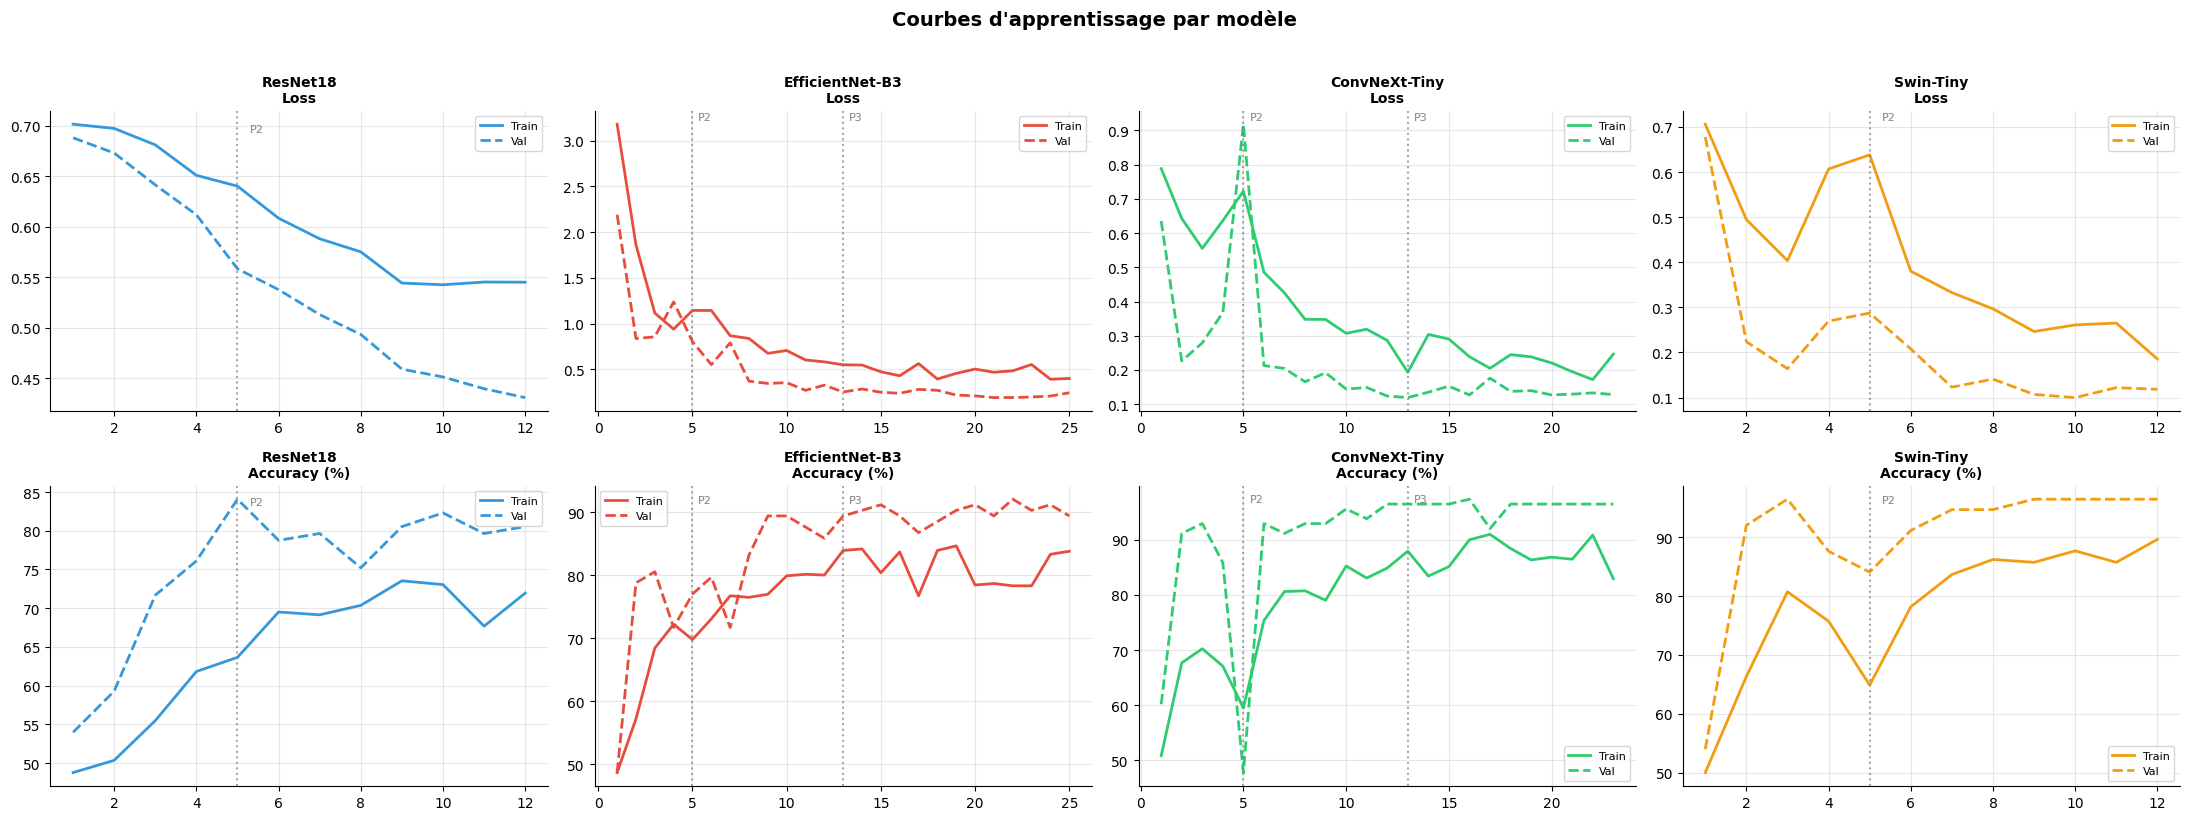

Figures sauvegardées : comparison_metrics.png | comparison_roc.png | comparison_curves.png


In [ ]:
COLORS = {
    'ResNet18'       : '#3498db',
    'EfficientNet-B3': '#e74c3c',
    'ConvNeXt-Tiny'  : '#2ecc71',
    'Swin-Tiny'      : '#f39c12',
}
model_names = list(ALL_RESULTS.keys())

# ── 1. Barres comparatives ─────────────────────────────────────────────
metrics_to_plot = [
    ('accuracy',      'Accuracy (%)'),
    ('recall_flood',  'Recall Inondation (%)'),
    ('f1',            'F1-Score (%)'),
    ('auc_roc',       'AUC-ROC'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (metric, label) in zip(axes, metrics_to_plot):
    vals   = [ALL_RESULTS[m][metric] for m in model_names]
    colors = [COLORS[m] for m in model_names]
    bars   = ax.bar(model_names, vals, color=colors, edgecolor='white', linewidth=1.5, width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylim(min(vals)*0.9, min(max(vals)*1.08, 100 if '%' in label else 1.05))
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Comparaison des métriques par modèle', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 2. Courbes ROC superposées ─────────────────────────────────────────
plt.figure(figsize=(8, 7))
for name in model_names:
    r = ALL_RESULTS[name]
    plt.plot(r['fpr'], r['tpr'], lw=2.5, color=COLORS[name],
             label=f"{name}  (AUC = {r['auc_roc']:.4f})")
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Aléatoire (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Courbes ROC — Comparaison des modèles', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_roc.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 3. Courbes d'apprentissage ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
for col, name in enumerate(model_names):
    h = ALL_RESULTS[name]['history']
    ep = range(1, len(h['train_loss'])+1)
    p1e = CONFIG['phase1_epochs']
    p2e = p1e + CONFIG['phase2_epochs']

    for ax, (train_k, val_k, ylabel) in zip(
            axes[:, col],
            [('train_loss','val_loss','Loss'), ('train_acc','val_acc','Accuracy (%)')]):
        ax.plot(ep, h[train_k], label='Train', color=COLORS[name], lw=2)
        ax.plot(ep, h[val_k],   label='Val',   color=COLORS[name], lw=2, linestyle='--')
        for x_phase, label_phase in [(p1e,'P2'),(p2e,'P3')]:
            if x_phase < len(ep):
                ax.axvline(x_phase, color='gray', linestyle=':', alpha=0.7)
                ax.text(x_phase+0.3, ax.get_ylim()[1]*0.97, label_phase,
                        fontsize=8, color='gray')
        ax.set_title(f'{name}\n{ylabel}', fontsize=10, fontweight='bold')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

plt.suptitle('Courbes d\'apprentissage par modèle', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figures sauvegardées : comparison_metrics.png | comparison_roc.png | comparison_curves.png")


## 9. Matrices de confusion comparatives

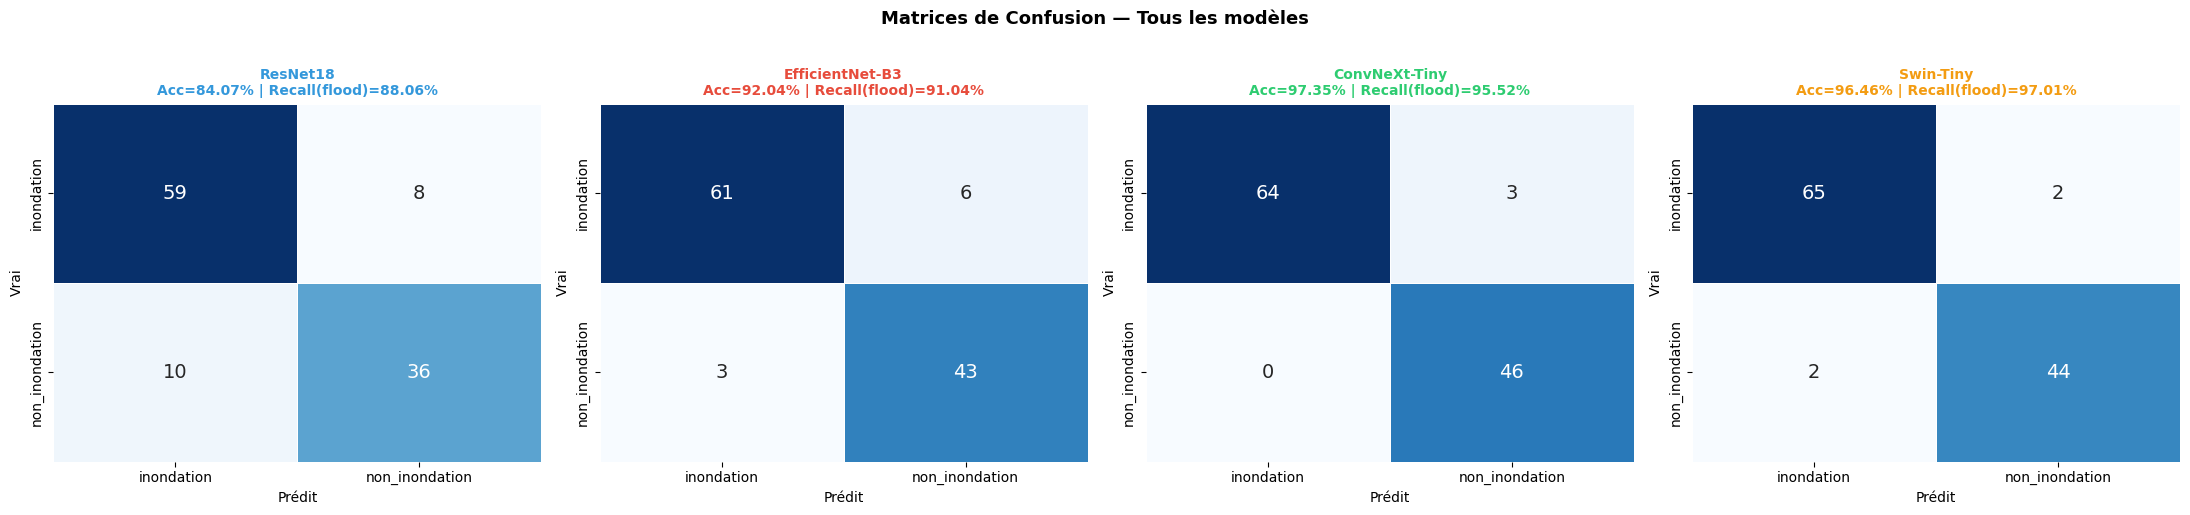

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
class_names = val_dataset.classes

for ax, name in zip(axes, model_names):
    r  = ALL_RESULTS[name]
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, cbar=False, annot_kws={'size':14})
    # Métriques clés sous le titre
    ax.set_title(
        f'{name}\nAcc={r["accuracy"]}% | Recall(flood)={r["recall_flood"]}%',
        fontsize=10, fontweight='bold', color=COLORS[name]
    )
    ax.set_xlabel('Prédit', fontsize=10)
    ax.set_ylabel('Vrai',   fontsize=10)

plt.suptitle('Matrices de Confusion — Tous les modèles', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_confusion.png', dpi=300, bbox_inches='tight')
plt.show()


## 10. Grad-CAM comparatif

Visualisation des zones d'attention pour **la même image** sur les 4 modèles.
Permet de voir si les Transformers (Swin) corrigent bien le problème d'attention locale.

In [ ]:
LABELS_EN = {'inondation': 'Flood', 'non_inondation': 'No flood'}

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.grads = None; self.acts = None
        target_layer.register_forward_hook(
            lambda m,i,o: setattr(self,'acts',o.detach() if isinstance(o,torch.Tensor) else o[0].detach()))
        target_layer.register_full_backward_hook(
            lambda m,gi,go: setattr(self,'grads',go[0].detach()))

    def generate(self, inp, class_idx=None):
        self.model.eval()
        out = self.model(inp)
        if class_idx is None: class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        # Swin renvoie des feature maps sans dimensions spatiales explicites
        # → on gère les deux cas (4D et 3D)
        acts = self.acts
        grads = self.grads
        if acts.dim() == 3:   # (B, seq, C) pour Swin
            B, N, C = acts.shape
            s = int(N**0.5)
            acts  = acts.reshape(B, s, s, C).permute(0,3,1,2)
            grads = grads.reshape(B, s, s, C).permute(0,3,1,2)
        w   = grads.mean(dim=(2,3), keepdim=True)
        cam = torch.relu((w * acts).sum(1, keepdim=True))
        cam = cam - cam.min()
        if cam.max() > 0: cam = cam / cam.max()
        return cam.squeeze().cpu().numpy(), class_idx


def get_target_layer(model_obj, model_name):
    """Retourne la dernière couche conv/attention selon l'architecture."""
    m = model_obj.model
    if 'resnet' in model_name.lower():
        return m.layer4[-1].conv2
    elif 'efficientnet' in model_name.lower():
        return m.blocks[-1][-1].conv_pwl
    elif 'convnext' in model_name.lower():
        return m.stages[-1].blocks[-1].conv_dw
    elif 'swin' in model_name.lower():
        return m.layers[-1].blocks[-1].norm1
    else:
        raise ValueError(f"Architecture inconnue: {model_name}")


def overlay(img_np, cam, alpha=0.5):
    h, w = img_np.shape[:2]
    cam_r = cv2.resize(cam.astype(np.float32), (w, h))
    heat  = cv2.cvtColor(cv2.applyColorMap(np.uint8(255*cam_r), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return (alpha*heat + (1-alpha)*img_np).astype(np.uint8)


# ── Visualisation : même image, 4 modèles ─────────────────────────────
def gradcam_comparison(all_results, val_dataset, device, num_images=4,
                       errors_only=True, save_path='comparison_gradcam.png'):
    display_tf = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor()])
    norm = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    model_names_local = list(all_results.keys())
    class_names = val_dataset.classes
    class_names_en = [LABELS_EN.get(c, c) for c in class_names]

    # Trouver des images candidates (erreurs communes ou aléatoires)
    candidates = []
    ref_model  = list(all_results.values())[0]['model_obj']
    for idx in range(len(val_dataset)):
        img_path, true_label = val_dataset.imgs[idx]
        pil = Image.open(img_path).convert('RGB')
        inp = norm(display_tf(pil)).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = ref_model(inp).argmax(1).item()
        if (not errors_only) or (pred != true_label):
            candidates.append((idx, img_path, true_label))
        if len(candidates) >= num_images: break

    if not candidates:
        print("Aucune erreur trouvée."); return

    n_cols = len(model_names_local) + 1   # original + 1 par modèle
    n_rows = len(candidates)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.5*n_rows))
    if n_rows == 1: axes = axes[np.newaxis,:]

    col_titles = ['Original image'] + model_names_local
    for j, t in enumerate(col_titles):
        axes[0,j].set_title(t, fontsize=11, fontweight='bold',
                            color=COLORS.get(t,'black') if j>0 else 'black')

    for row, (idx, img_path, true_label) in enumerate(candidates):
        pil  = Image.open(img_path).convert('RGB')
        disp = display_tf(pil)
        orig_np = (disp.permute(1,2,0).numpy()*255).astype(np.uint8)
        inp  = norm(disp).unsqueeze(0).to(device)

        axes[row,0].imshow(orig_np)
        axes[row,0].set_ylabel(f"True: {class_names_en[true_label]}", fontsize=9)
        axes[row,0].axis('off')

        for col, name in enumerate(model_names_local, start=1):
            m_obj = all_results[name]['model_obj']
            try:
                tl = get_target_layer(m_obj, name)
                gc = GradCAM(m_obj, tl)
                cam, pred_cls = gc.generate(inp)
                ov = overlay(orig_np, cam)
                conf = torch.softmax(m_obj(inp),1)[0,pred_cls].item()
                color = 'green' if pred_cls == true_label else 'red'
                axes[row,col].imshow(ov)
                axes[row,col].set_title(
                    f"{class_names_en[pred_cls]} ({conf:.0%})",
                    fontsize=9, color=color)
            except Exception as e:
                axes[row,col].text(0.5,0.5,str(e),ha='center',va='center',fontsize=7,wrap=True)
            axes[row,col].axis('off')

    plt.suptitle('Comparative Grad-CAM — attention maps per model',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Sauvegardé : {save_path}")


gradcam_comparison(ALL_RESULTS, val_dataset, device,
                   num_images=4, errors_only=True,
                   save_path='comparison_gradcam.png')


## 11. Synthèse finale — Recommandation pour le mémoire

In [ ]:
print("\n" + "="*70)
print("SYNTHÈSE COMPARATIVE")
print("="*70)

# Meilleur modèle par métrique clé
best_acc   = max(ALL_RESULTS, key=lambda m: ALL_RESULTS[m]['accuracy'])
best_rec   = max(ALL_RESULTS, key=lambda m: ALL_RESULTS[m]['recall_flood'])
best_f1    = max(ALL_RESULTS, key=lambda m: ALL_RESULTS[m]['f1'])
best_auc   = max(ALL_RESULTS, key=lambda m: ALL_RESULTS[m]['auc_roc'])
fastest    = min(ALL_RESULTS, key=lambda m: ALL_RESULTS[m]['train_time_min'])

print(f"\n🏆 Meilleure Accuracy        : {best_acc:20s} ({ALL_RESULTS[best_acc]['accuracy']}%)")
print(f"🏆 Meilleur Recall Inondation : {best_rec:20s} ({ALL_RESULTS[best_rec]['recall_flood']}%)")
print(f"🏆 Meilleur F1-Score         : {best_f1:20s} ({ALL_RESULTS[best_f1]['f1']}%)")
print(f"🏆 Meilleur AUC-ROC          : {best_auc:20s} ({ALL_RESULTS[best_auc]['auc_roc']:.4f})")
print(f"⚡ Plus rapide               : {fastest:20s} ({ALL_RESULTS[fastest]['train_time_min']} min)")

# Recommendation automatique basée sur recall flood (priorité application réelle)
best_overall = best_rec
print(f"\n{'='*70}")
print(f"RECOMMANDATION : {best_overall}")
print(f"  → Meilleur recall sur les inondations ({ALL_RESULTS[best_overall]['recall_flood']}%)")
print(f"  → F1 = {ALL_RESULTS[best_overall]['f1']}% | AUC = {ALL_RESULTS[best_overall]['auc_roc']:.4f}")
print(f"{'='*70}")

print("\nFichiers générés pour le mémoire :")
files = [
    'comparison_table.png    — Tableau complet (Figure 1)',
    'comparison_metrics.png  — Barres comparatives (Figure 2)',
    'comparison_roc.png      — ROC superposées (Figure 3)',
    'comparison_curves.png   — Courbes apprentissage (Figure 4)',
    'comparison_confusion.png— Matrices de confusion (Figure 5)',
    'comparison_gradcam.png  — Grad-CAM comparatif (Figure 6)',
    'comparison_results.csv  — Données brutes pour tableaux LaTeX',
]
for f in files:
    print(f"  📄 {f}")



SYNTHÈSE COMPARATIVE

🏆 Meilleure Accuracy        : ConvNeXt-Tiny        (97.35%)
🏆 Meilleur Recall Inondation : Swin-Tiny            (97.01%)
🏆 Meilleur F1-Score         : ConvNeXt-Tiny        (97.36%)
🏆 Meilleur AUC-ROC          : Swin-Tiny            (0.9932)
⚡ Plus rapide               : ResNet18             (2.8 min)

RECOMMANDATION : Swin-Tiny
  → Meilleur recall sur les inondations (97.01%)
  → F1 = 96.46% | AUC = 0.9932

Fichiers générés pour le mémoire :
  📄 comparison_table.png    — Tableau complet (Figure 1)
  📄 comparison_metrics.png  — Barres comparatives (Figure 2)
  📄 comparison_roc.png      — ROC superposées (Figure 3)
  📄 comparison_curves.png   — Courbes apprentissage (Figure 4)
  📄 comparison_confusion.png— Matrices de confusion (Figure 5)
  📄 comparison_gradcam.png  — Grad-CAM comparatif (Figure 6)
  📄 comparison_results.csv  — Données brutes pour tableaux LaTeX


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
